# **LAB Session 3 & 4 Speech Recognition**

In [ ]:
import os
import numpy as np
import scipy
from scipy.io import wavfile
import scipy.fftpack as fft
from scipy.signal import get_window
from IPython.display import display, Audio
import matplotlib.pyplot as plt

SAMPLE = 'sample_audio.wav'


In [2]:
sample_rate, audio = wavfile.read(SAMPLE)

In [3]:
print(f"sample_rate: ", sample_rate)

sample_rate:  16000


In [4]:
audio = audio / np.max(np.abs(audio))

In [5]:
def frame_audio(audio, FFT_size, hop_size, sample_rate):
  audio = np.pad(audio, int(FFT_size/2), mode="reflect")
  frame_len = np.round(sample_rate * (hop_size / 1000)).astype(int)
  frame_num = int((len(audio) - FFT_size) / frame_len) +1
  frames = np.zeros((frame_num, FFT_size))

  for i in range (frame_num):
    frames[i] = audio[i*frame_len : i*frame_len + FFT_size]
  return frames

In [6]:
hop_size = 15
FFT_size = 2048
audio_framed = frame_audio(audio, FFT_size, hop_size, sample_rate)
audio_framed.shape

(1033, 2048)

In [7]:
window = get_window("hann", FFT_size, fftbins = True)
audio_win = audio_framed * window
audio_winT = np.transpose(audio_win)
audio_winT.shape

(2048, 1033)

In [8]:
audio_fft = np.empty((int(1 + FFT_size // 2), audio_winT.shape[1]), dtype=np.complex64, order='F')

for i in range(audio_fft.shape[1]):
  audio_fft[:, i] = fft.fft(audio_winT[:, i], axis = 0)[:audio_fft.shape[0]]

audio_fft = np.transpose(audio_fft)
audio_fft.shape

(1033, 1025)

In [9]:
audio_power = np.square(np.abs(audio_fft))
audio_power.shape

(1033, 1025)

### **session 4**

In [10]:
# Mel Filterbank
freq_min = 0
freq_high = sample_rate / 2
mel_filter_num = 10

In [11]:
# rumus konversi frekuensi ke mel dan sebaliknya
def freq_to_mel(freq):
  return 2595.0 * np.log10(1.0 + freq / 700)

def mel_to_freq(mels):
  return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

In [14]:
# filter points
def get_filter_points(fmin, fmax, mel_filter_num, FFT_size, sample_rate):
  fmin_mel = freq_to_mel(fmin)
  fmax_mel = freq_to_mel(fmax)

  mels = np.linspace(fmin_mel, fmax_mel, num = mel_filter_num + 2)
  freqs = mel_to_freq(mels)
  
  return((FFT_size + 1) / sample_rate * freqs).astype(int), freqs

In [15]:
filter_points, mel_freqs = get_filter_points(freq_min, freq_high, mel_filter_num, FFT_size, sample_rate)
print(filter_points)
print(mel_freqs)

[   0   23   52   88  134  192  264  355  470  614  796 1024]
[   0.          180.21928115  406.83711843  691.7991039  1050.12629534
 1500.70701371 2067.29249375 2779.74887082 3675.63149949 4802.16459006
 6218.73051459 8000.        ]


In [39]:
def get_filters(filter_points, FFT_size):
  filter = np.zeros((len(filter_points) - 2, int(FFT_size / 2 + 1))) # -2 karena kita cuma butuh 10, tadi kan ada 12 filter points, tapi kita cuma butuh 10 filter 

  for i in range(len(filter_points) - 2): # ini slicing untuk filter points, karena kita cuma butuh 10 filter, jadi kita slicing dari 0-9
    filter[i, filter_points[i] : filter_points[i + 1]] = np.linspace(0, 1, filter_points[i+1] - filter_points[i]) # np.linspace untuk gambar garis segitiga dari point 1-2
    filter[i, filter_points[i+1] : filter_points[i + 2]] = np.linspace(1, 0, filter_points[i+2] - filter_points[i+1]) # np.linspace untuk gambar garis segitiga dari point 2-3

  return filter

In [40]:
filters = get_filters(filter_points, FFT_size)
filters.shape

(10, 1025)

In [ ]:
# Normalisasi filter bank
enorm = 2.0 / (mel_freqs[2:mel_filter_num+2] - mel_freqs[:mel_filter_num])
enorm.shape

(10,)

In [42]:
enorm = enorm[:, np.newaxis]
enorm.shape

(10, 1)

In [43]:
filters = filters * enorm

In [44]:
audio_filtered = np.dot(filters, np.transpose(audio_power))
audio_log = 10.0 * np.log10(audio_filtered)
audio_log.shape

(10, 1033)

In [45]:
def dct(dct_filter_num, filter_len):
  basis = np.empty((dct_filter_num, filter_len))
  basis[0, :] = 1.0 / np.sqrt(filter_len)

  samples = np.arange(1, 2 * filter_len, 2) * np.pi / (2.0 * filter_len)

  for i in range(1, dct_filter_num):
    basis[i, :] = np.cos(i * samples) * np.sqrt(2.0 / filter_len)
  return basis

In [46]:
dct_filter_num = 40
dct_filters = dct(dct_filter_num, mel_filter_num)
dct_filters.shape

(40, 10)

In [47]:
cepstral_coefficients = np.dot(dct_filters, audio_log)
cepstral_coefficients.shape

(40, 1033)

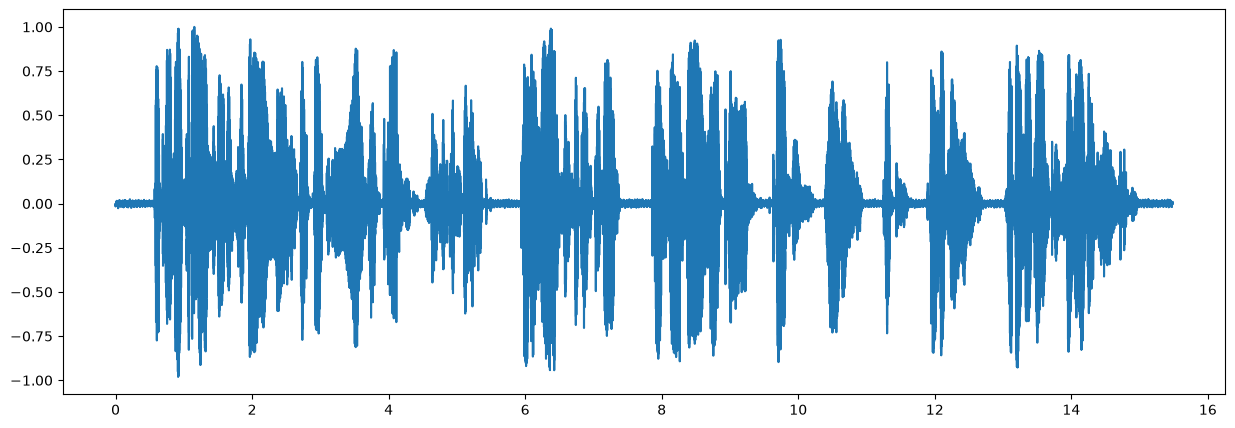

In [48]:
plt.figure(figsize=(15,5))
plt.plot(np.linspace(0, len(audio) / sample_rate, num = len(audio)), audio)

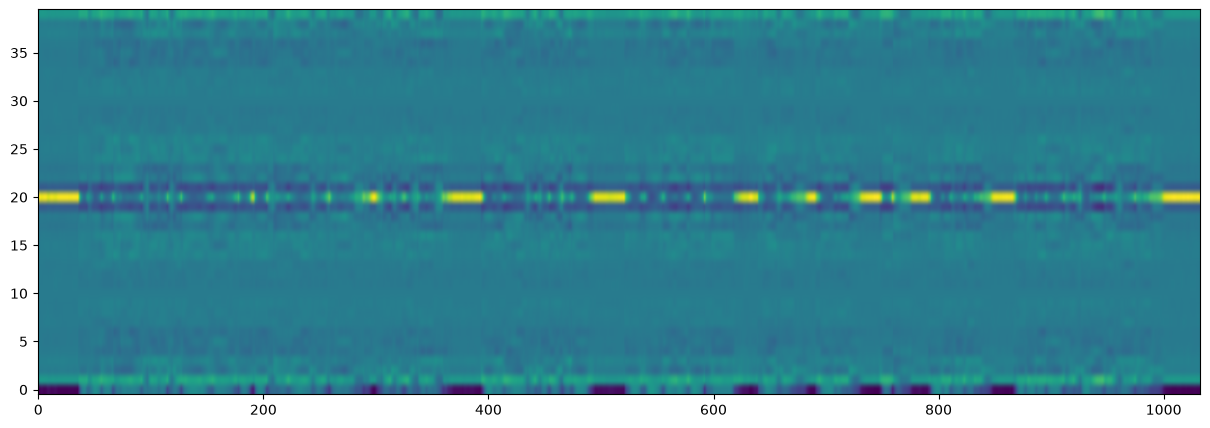

In [49]:
plt.figure(figsize=(15,5))
plt.imshow(cepstral_coefficients, aspect = "auto", origin = "lower")